In [4]:
import pandas as pd

file_path = "/Users/teesinad/Documents/school/DataSci/ClassWork/DataSciPython/RealestateAnalize/dataset/Real_estate.csv"
df = pd.read_csv(file_path)

print(df.head())

   No  transaction date  house age  distance to the nearest MRT station  \
0   1          2012.917       32.0                             84.87882   
1   2          2012.917       19.5                            306.59470   
2   3          2013.583       13.3                            561.98450   
3   4          2013.500       13.3                            561.98450   
4   5          2012.833        5.0                            390.56840   

   number of convenience stores  latitude  longitude  house price of unit area  
0                            10  24.98298  121.54024                      37.9  
1                             9  24.98034  121.53951                      42.2  
2                             5  24.98746  121.54391                      47.3  
3                             5  24.98746  121.54391                      54.8  
4                             5  24.97937  121.54245                      43.1  


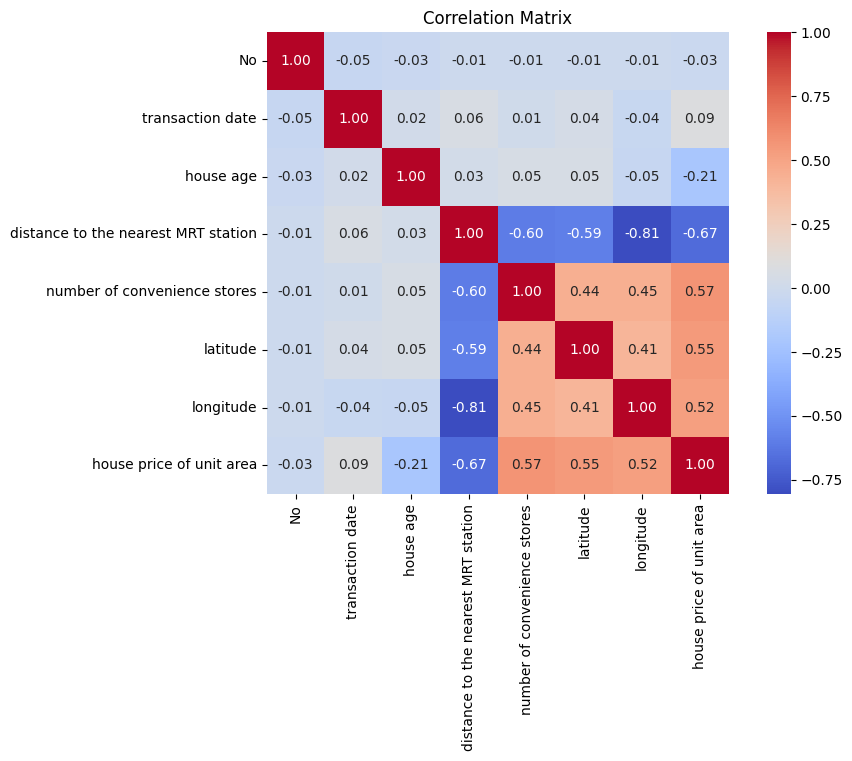

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

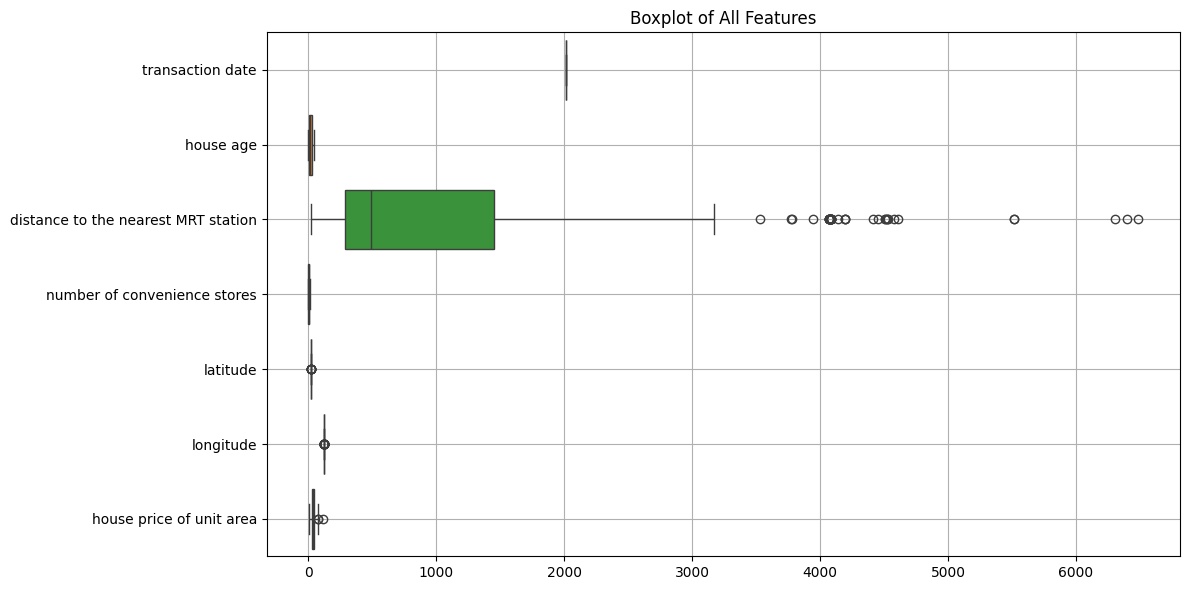

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ถ้ามีคอลัมน์ 'No' ที่ไม่เกี่ยวข้อง ให้ลบทิ้ง
df = df.drop(columns=["No"], errors="ignore")

# วาด Boxplot ของทุกคอลัมน์แนวนอน
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot of All Features")
plt.tight_layout()
plt.grid(True)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

X = df.drop(columns=["house price of unit area"])
y = df["house price of unit area"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
degree = 2
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

model.fit(X_train, y_train)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Polynomial Degree: {degree}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Polynomial Degree: 2
Mean Squared Error: 40.63
R² Score: 0.76


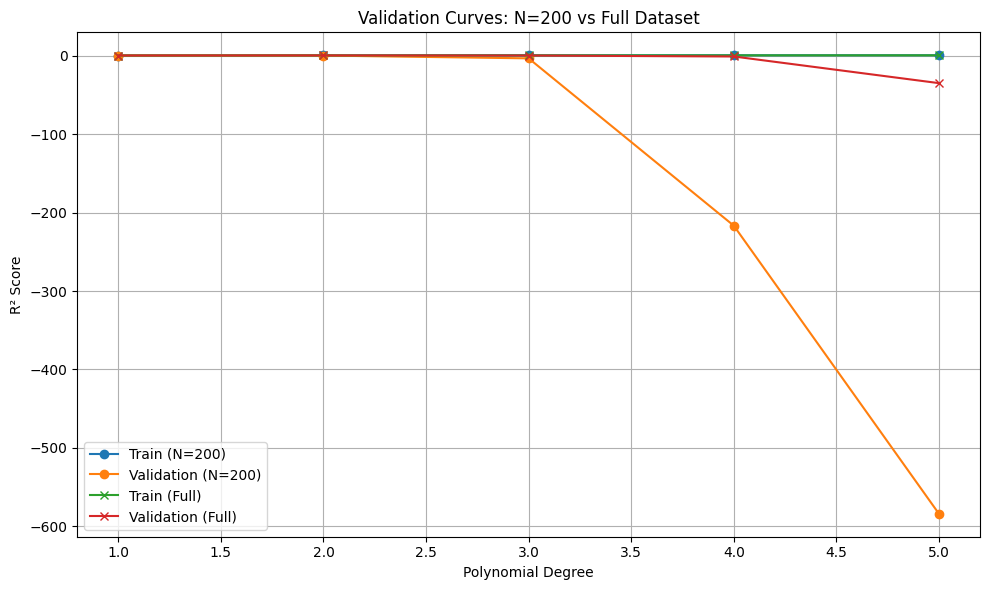

In [15]:
from sklearn.model_selection import validation_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# เตรียมข้อมูล
X = df.drop(columns=["house_price"])
y = df["house_price"]

# แบ่งข้อมูล N=200
X_200, _, y_200, _ = train_test_split(X, y, train_size=200, random_state=42)

# ช่วง degree
degrees = range(1, 6)

# Validation Curve: N=200
train_scores_200, val_scores_200 = validation_curve(
    make_pipeline(PolynomialFeatures(), LinearRegression()),
    X_200, y_200,
    param_name="polynomialfeatures__degree",
    param_range=degrees,
    cv=5,
    scoring="r2"
)

# Validation Curve: Full
train_scores_full, val_scores_full = validation_curve(
    make_pipeline(PolynomialFeatures(), LinearRegression()),
    X, y,
    param_name="polynomialfeatures__degree",
    param_range=degrees,
    cv=5,
    scoring="r2"
)

# หาค่าเฉลี่ย
mean_train_200 = np.mean(train_scores_200, axis=1)
mean_val_200 = np.mean(val_scores_200, axis=1)
mean_train_full = np.mean(train_scores_full, axis=1)
mean_val_full = np.mean(val_scores_full, axis=1)

# วาดกราฟ
plt.figure(figsize=(10, 6))
plt.plot(degrees, mean_train_200, label="Train (N=200)", marker='o')
plt.plot(degrees, mean_val_200, label="Validation (N=200)", marker='o')
plt.plot(degrees, mean_train_full, label="Train (Full)", marker='x')
plt.plot(degrees, mean_val_full, label="Validation (Full)", marker='x')
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Validation Curves: N=200 vs Full Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

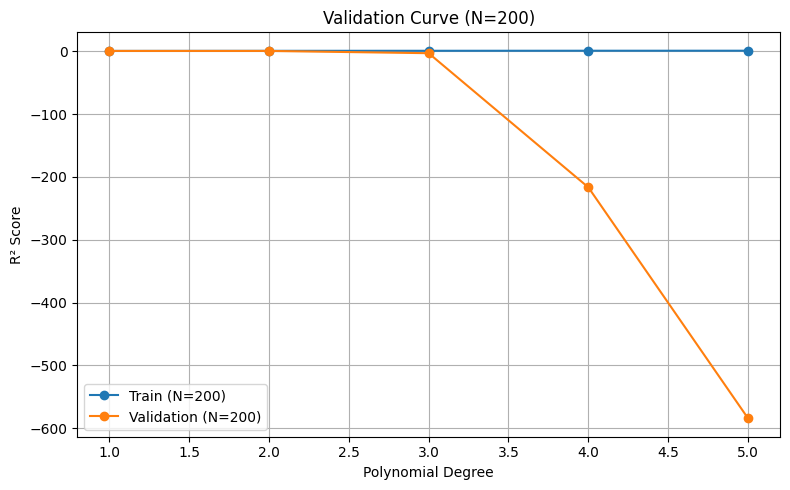

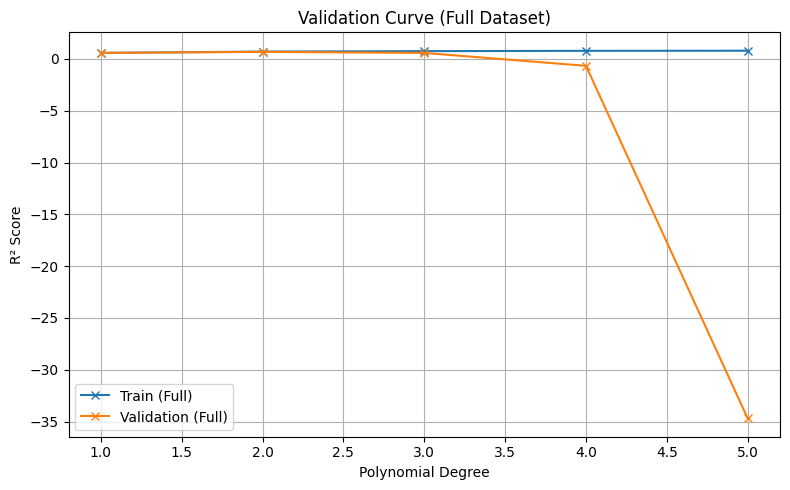

In [16]:

plt.figure(figsize=(8, 5))
plt.plot(degrees, mean_train_200, label="Train (N=200)", marker='o')
plt.plot(degrees, mean_val_200, label="Validation (N=200)", marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Validation Curve (N=200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(degrees, mean_train_full, label="Train (Full)", marker='x')
plt.plot(degrees, mean_val_full, label="Validation (Full)", marker='x')
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Validation Curve (Full Dataset)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

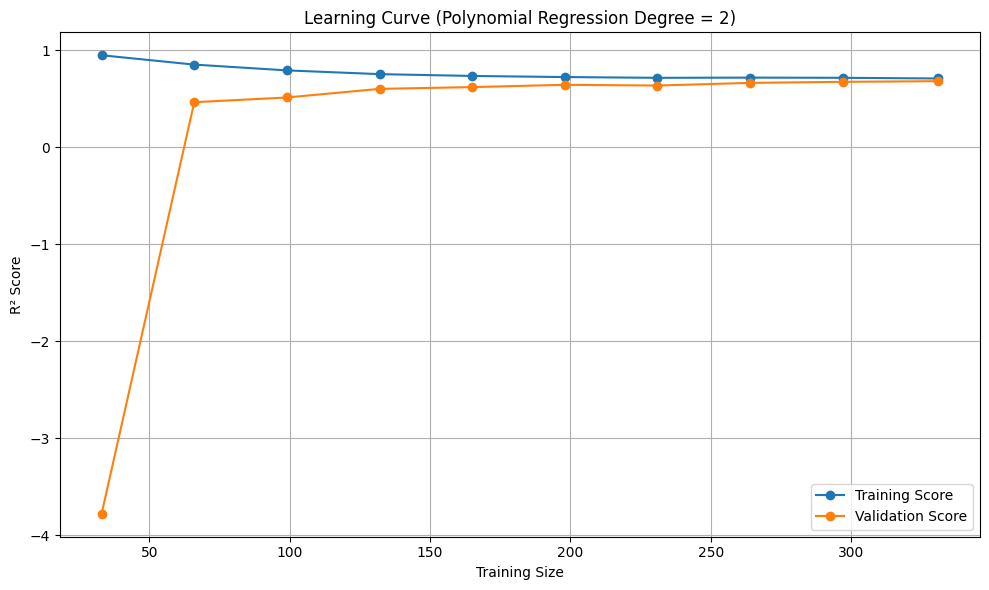

In [ ]:
from sklearn.model_selection import learning_curve

model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

train_sizes, train_scores, val_scores = learning_curve(
    model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    shuffle=True,
    random_state=42
)

# คำนวณค่าเฉลี่ย
mean_train_scores = np.mean(train_scores, axis=1)
mean_val_scores = np.mean(val_scores, axis=1)

# วาดกราฟ Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, mean_train_scores, 'o-', label="Training Score")
plt.plot(train_sizes, mean_val_scores, 'o-', label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve (Polynomial Regression Degree = 2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()